Proyecto Final Ecuaciones Diferenciales 


In [2]:
##Imports 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import fsolve

# Configurar matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ Importaciones completadas")

✓ Importaciones completadas


In [3]:
class MetodosNumericos:
## Nuestro 3 metodos numéricos: Euler explícito, Heun (RK2) y RK4
    def __init__(self, f, t0, tf, y0, h):
        self.f = f
        self.t0 = t0
        self.tf = tf
        self.y0 = np.atleast_1d(y0)
        self.h = h
        self.t = np.arange(t0, tf + h, h)
        self.n = len(self.t)
        self.is_system = self.y0.size > 1

    def euler_explicito(self):
        if self.is_system:
            y = np.zeros((self.n, self.y0.size))
        else:
            y = np.zeros(self.n)
        y[0] = self.y0

        for i in range(self.n - 1):
            y[i + 1] = y[i] + self.h * self.f(self.t[i], y[i])

        return self.t, y

    def heun_rk2(self):
        if self.is_system:
            y = np.zeros((self.n, self.y0.size))
        else:
            y = np.zeros(self.n)
        y[0] = self.y0

        for i in range(self.n - 1):
            y_pred = y[i] + self.h * self.f(self.t[i], y[i])
            y[i + 1] = y[i] + (self.h / 2) * (self.f(self.t[i], y[i]) + self.f(self.t[i + 1], y_pred))

        return self.t, y

    def rk4(self):
        if self.is_system:
            y = np.zeros((self.n, self.y0.size))
        else:
            y = np.zeros(self.n)
        y[0] = self.y0

        for i in range(self.n - 1):
            k1 = self.f(self.t[i], y[i])
            k2 = self.f(self.t[i] + self.h/2, y[i] + (self.h/2)*k1)
            k3 = self.f(self.t[i] + self.h/2, y[i] + (self.h/2)*k2)
            k4 = self.f(self.t[i] + self.h, y[i] + self.h*k3)
            y[i + 1] = y[i] + (self.h/6) * (k1 + 2*k2 + 2*k3 + k4)

        return self.t, y

    def calcular_error(self, y_numerica, y_exacta):
        ###Calcula el error global máximo
        return np.max(np.abs(y_numerica - y_exacta))

print("✓ Clase MetodosNumericos definida")

✓ Clase MetodosNumericos definida


In [4]:
##Def de algunas ecuaciones de prueba para validar nuestros metodos numéricos
class EcuacionesPrueba:

    # PRIMER ORDEN
    @staticmethod
    def edo1_primer_orden(t, y):
        """y' = -x + y, y(0) = 1"""
        return -t + y

    @staticmethod
    def edo3_primer_orden(t, y):
        """y' = y * cos(x), y(0) = 1"""
        return y * np.cos(t)

    # SEGUNDO ORDEN (como sistemas)
    @staticmethod
    def edo1_segundo_orden(t, y):
        """y'' + 4y = 0, y(0) = 1, y'(0) = 0"""
        y1, y2 = y
        return np.array([y2, -4*y1])

    # SISTEMAS LINEALES 2x2
    @staticmethod
    def sistema1_lineal(t, y):
        """x' = 3x - 5y, y' = 8x - 12y"""
        x, y_var = y
        return np.array([3*x - 5*y_var, 8*x - 12*y_var])

    @staticmethod
    def sistema2_lineal(t, y):
        """dx/dt = x + y, dy/dt = 2y"""
        x, y_var = y
        return np.array([x + y_var, 2*y_var])

    # SISTEMAS NO LINEALES (Lotka-Volterra)
    @staticmethod
    def lotka_volterra2(t, y):
        """dx/dt = 1.1x - 0.4xy, dy/dt = 0.1xy - 0.4y"""
        x, y_var = y
        return np.array([1.1*x - 0.4*x*y_var, 0.1*x*y_var - 0.4*y_var])

print("Ecuaciones de prueba definidas")

Ecuaciones de prueba definidas


In [5]:

pasos_h = np.array([0.40, 0.20, 0.10, 0.05])

# Ecuación 1: y' = -x + y
print("\n" + "="*70)
print("PRUEBA 1: y' = -x + y, y(0) = 1")
print("="*70)

# Usar RK4 con h=0.01 como referencia fina
solver_ref_fino = MetodosNumericos(EcuacionesPrueba.edo1_primer_orden, 0, 10, 1.0, 0.01)
t_ref_fino, y_ref_fino = solver_ref_fino.rk4()

# Convertir a 2D para tratamiento uniforme (caso escalar: reshape a (n, 1))
if y_ref_fino.ndim == 1:
    y_ref_fino = y_ref_fino.reshape(-1, 1)

resultados = []
for h in pasos_h:
    solver = MetodosNumericos(EcuacionesPrueba.edo1_primer_orden, 0, 10, 1.0, h)
    t_euler, y_euler = solver.euler_explicito()
    t_heun, y_heun = solver.heun_rk2()
    t_rk4, y_rk4 = solver.rk4()

    # Interpolar cada componente
    n_components = y_ref_fino.shape[1]
    y_ref_euler = np.array([np.interp(t_euler, t_ref_fino, y_ref_fino[:, i]) for i in range(n_components)]).T
    y_ref_heun = np.array([np.interp(t_heun, t_ref_fino, y_ref_fino[:, i]) for i in range(n_components)]).T
    y_ref_rk4 = np.array([np.interp(t_rk4, t_ref_fino, y_ref_fino[:, i]) for i in range(n_components)]).T

    # Convertir soluciones escalares a 2D si es necesario
    if y_euler.ndim == 1:
        y_euler = y_euler.reshape(-1, 1)
    if y_heun.ndim == 1:
        y_heun = y_heun.reshape(-1, 1)
    if y_rk4.ndim == 1:
        y_rk4 = y_rk4.reshape(-1, 1)

    error_euler = np.max(np.abs(y_euler - y_ref_euler))
    error_heun = np.max(np.abs(y_heun - y_ref_heun))
    error_rk4 = np.max(np.abs(y_rk4 - y_ref_rk4))

    resultados.append({'h': h, 'Euler': error_euler, 'Heun (RK2)': error_heun, 'RK4': error_rk4})

df_primer = pd.DataFrame(resultados)
print("\nErrores globales máximos:")
print(df_primer.to_string(index=False))


PRUEBA 1: y' = -x + y, y(0) = 1

Errores globales máximos:
   h        Euler   Heun (RK2)          RK4
0.40 2.466471e-11 2.384759e-11 2.329337e-11
0.20 2.339995e-11 2.168576e-11 2.004086e-11
0.10 2.748024e-11 2.787637e-11 2.796519e-11
0.05 2.267164e-11 2.237144e-11 2.210143e-11


/var/folders/vm/k_mjz20557g1693w1k38dfsh0000gn/T/ipykernel_89323/4144076005.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[0] = self.y0
/var/folders/vm/k_mjz20557g1693w1k38dfsh0000gn/T/ipykernel_89323/4144076005.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[0] = self.y0
/var/folders/vm/k_mjz20557g1693w1k38dfsh0000gn/T/ipykernel_89323/4144076005.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y[0] = self.y0


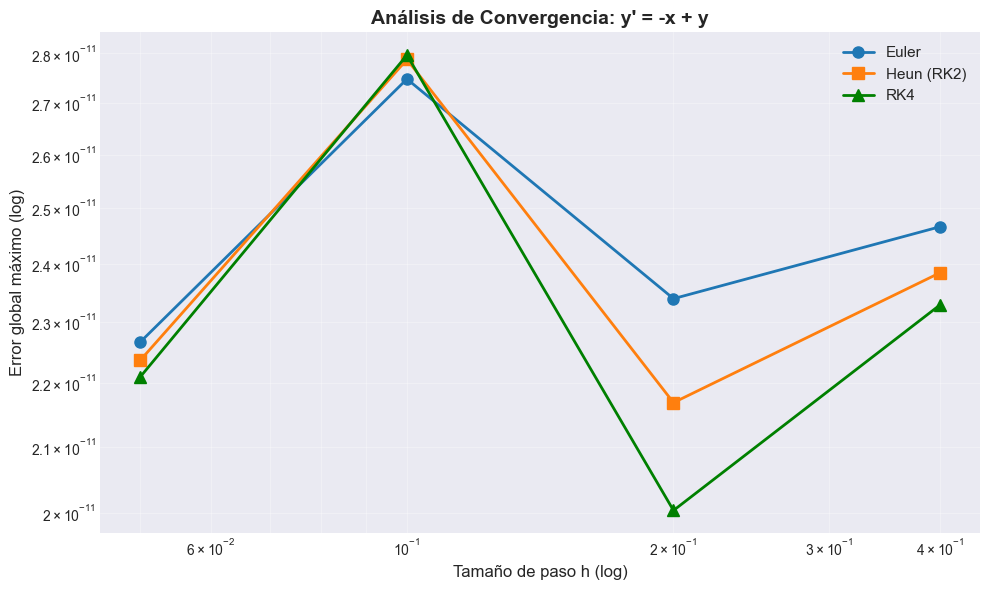

In [6]:
# Gráfico Log-Log
fig, ax = plt.subplots(figsize=(10, 6))

err_euler = df_primer['Euler'].values
err_heun = df_primer['Heun (RK2)'].values
err_rk4 = df_primer['RK4'].values

ax.loglog(pasos_h, err_euler, 'o-', label='Euler', linewidth=2, markersize=8)
ax.loglog(pasos_h, err_heun, 's-', label='Heun (RK2)', linewidth=2, markersize=8)
ax.loglog(pasos_h, err_rk4, '^-', label='RK4', linewidth=2, markersize=8, color='green')

ax.set_xlabel('Tamaño de paso h (log)', fontsize=12)
ax.set_ylabel('Error global máximo (log)', fontsize=12)
ax.set_title('Análisis de Convergencia: y\' = -x + y', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Sistema 1: x' = 3x - 5y, y' = 8x - 12y
print("\n" + "="*70)
print("PRUEBA 2: Sistema Lineal 2x2")
print("x' = 3x - 5y, y' = 8x - 12y")
print("="*70)

# Usar RK4 con h=0.01 como referencia fina
solver_ref_fino = MetodosNumericos(EcuacionesPrueba.sistema1_lineal, 0, 10, np.array([1.0, 1.0]), 0.01)
t_ref_fino, y_ref_fino = solver_ref_fino.rk4()

resultados = []
for h in pasos_h:
    solver = MetodosNumericos(EcuacionesPrueba.sistema1_lineal, 0, 10, np.array([1.0, 1.0]), h)
    t_euler, y_euler = solver.euler_explicito()
    t_heun, y_heun = solver.heun_rk2()
    t_rk4, y_rk4 = solver.rk4()

    # Interpolar referencia componente a componente
    y_ref_euler = np.array([np.interp(t_euler, t_ref_fino, y_ref_fino[:, i]) for i in range(2)]).T
    y_ref_heun = np.array([np.interp(t_heun, t_ref_fino, y_ref_fino[:, i]) for i in range(2)]).T
    y_ref_rk4 = np.array([np.interp(t_rk4, t_ref_fino, y_ref_fino[:, i]) for i in range(2)]).T

    error_euler = np.max(np.abs(y_euler - y_ref_euler))
    error_heun = np.max(np.abs(y_heun - y_ref_heun))
    error_rk4 = np.max(np.abs(y_rk4 - y_ref_rk4))

    resultados.append({'h': h, 'Euler': error_euler, 'Heun (RK2)': error_heun, 'RK4': error_rk4})

df_sistema = pd.DataFrame(resultados)
print("\nErrores globales máximos:")
print(df_sistema.to_string(index=False))


PRUEBA 2: Sistema Lineal 2x2
x' = 3x - 5y, y' = 8x - 12y

Errores globales máximos:
   h        Euler   Heun (RK2)          RK4
0.40 1.595592e+09 9.124161e+12 2.058164e+09
0.20 3.912259e-01 2.487741e-01 4.077408e-02
0.10 1.228928e-01 3.710721e-02 1.440546e-03
0.05 4.289279e-02 6.732212e-03 6.271078e-05


In [8]:
# Lotka-Volterra 2: dx/dt = 1.1x - 0.4xy, dy/dt = 0.1xy - 0.4y
print("\n" + "="*70)
print("PRUEBA 3: Sistema No Lineal (Lotka-Volterra)")
print("dx/dt = 1.1x - 0.4xy, dy/dt = 0.1xy - 0.4y")
print("x(0) = 10, y(0) = 5")
print("="*70)

# Resolver con los 3 métodos
h = 0.05
solver = MetodosNumericos(EcuacionesPrueba.lotka_volterra2, 0, 10, np.array([10.0, 5.0]), h)
t_euler, y_euler = solver.euler_explicito()
t_heun, y_heun = solver.heun_rk2()
t_rk4, y_rk4 = solver.rk4()

print(f"\nSimulación completada con h = {h}")
print(f"Puntos de tiempo: {len(t_rk4)}")


PRUEBA 3: Sistema No Lineal (Lotka-Volterra)
dx/dt = 1.1x - 0.4xy, dy/dt = 0.1xy - 0.4y
x(0) = 10, y(0) = 5

Simulación completada con h = 0.05
Puntos de tiempo: 201


In [ ]:
## Visualizacion Dinamicas temporales 
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Presas
axes[0].plot(t_euler, y_euler[:, 0], 'o-', label='Euler', alpha=0.7, linewidth=1.5)
axes[0].plot(t_heun, y_heun[:, 0], 's-', label='Heun', alpha=0.7, linewidth=1.5)
axes[0].plot(t_rk4, y_rk4[:, 0], '^-', label='RK4', alpha=0.7, linewidth=1.5, color='green')
axes[0].set_ylabel('Presas x(t)', fontsize=12)
axes[0].set_title('Dinámicas Temporales - Lotka-Volterra', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Depredadores
axes[1].plot(t_euler, y_euler[:, 1], 'o-', label='Euler', alpha=0.7, linewidth=1.5)
axes[1].plot(t_heun, y_heun[:, 1], 's-', label='Heun', alpha=0.7, linewidth=1.5)
axes[1].plot(t_rk4, y_rk4[:, 1], '^-', label='RK4', alpha=0.7, linewidth=1.5, color='green')
axes[1].set_xlabel('Tiempo t', fontsize=12)
axes[1].set_ylabel('Depredadores y(t)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()